In [1]:
import pandas as pd
import numpy as np

train_df = pd.read_parquet(
    "data/processed/train_ready_modeling.parquet"
)

valid_df = pd.read_parquet(
    "data/processed/valid_ready_modeling.parquet"
)

print(train_df.shape)
print(valid_df.shape)

(472432, 486)
(118108, 486)


Separar X/y

In [2]:
X_train = train_df.drop(
    columns=["isFraud", "TransactionID"]
)

y_train = train_df["isFraud"]

X_valid = valid_df.drop(
    columns=["isFraud", "TransactionID"]
)

y_valid = valid_df["isFraud"]

print(X_train.shape)
print(X_valid.shape)

(472432, 484)
(118108, 484)


In [3]:
import gc

del train_df
del valid_df

gc.collect()

0

## Primer Modelo: RandomForestClassifier

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_valid)
y_proba = rf_model.predict_proba(X_valid)[:, 1]

print("ROC-AUC:", roc_auc_score(y_valid, y_proba))
print("\nMatriz de confusión:")
print(confusion_matrix(y_valid, y_pred))

print("\nReporte:")
print(classification_report(y_valid, y_pred))

ROC-AUC: 0.8751272517900951

Matriz de confusión:
[[101092  12952]
 [  1249   2815]]

Reporte:
              precision    recall  f1-score   support

           0       0.99      0.89      0.93    114044
           1       0.18      0.69      0.28      4064

    accuracy                           0.88    118108
   macro avg       0.58      0.79      0.61    118108
weighted avg       0.96      0.88      0.91    118108



El Random Forest baseline obtuvo un ROC-AUC de 0.875, evidenciando capacidad discriminativa significativa para distinguir transacciones fraudulentas. El modelo alcanzó un recall de 69% sobre la clase fraudulenta, mostrando buena capacidad de detección, aunque acompañado de una precisión reducida (18%), reflejando un alto número de falsos positivos. Esto sugiere la necesidad de optimizar el balance entre sensibilidad y precisión mediante ajuste de hiperparámetros y threshold tuning.

### Feature Importance

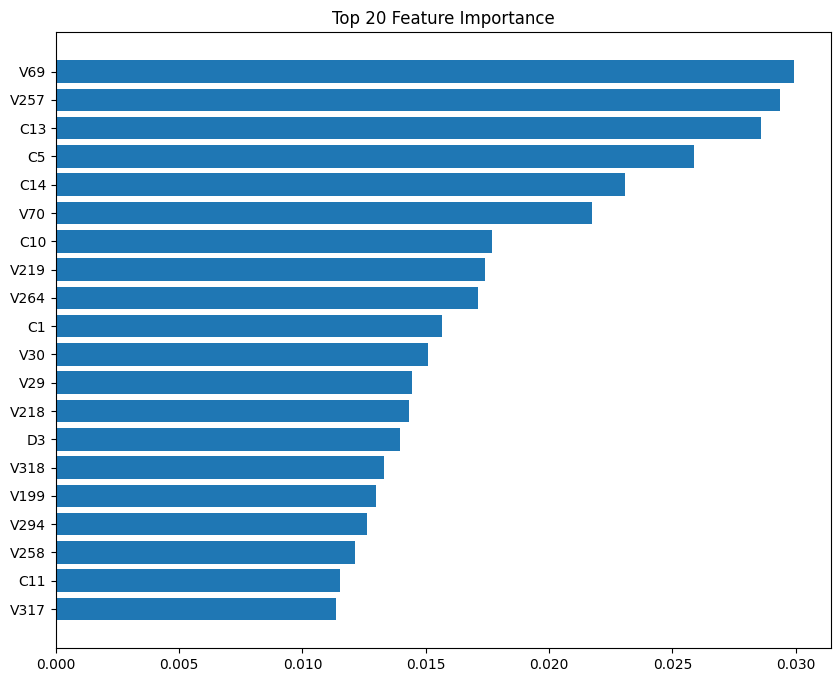

,feature,importance
109,V69,0.029928
297,V257,0.029380
24,C13,0.028599
16,C5,0.025876
25,C14,0.023084
110,V70,0.021746
21,C10,0.017684
259,V219,0.017415
304,V264,0.017118
12,C1,0.015651


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="importance",
        ascending=False
    )
)

top_20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_20["feature"],
    top_20["importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 20 Feature Importance"
)

plt.show()

display(top_20)

El análisis de importancia de variables mostró que el modelo depende principalmente de variables engineered (Vxxx) y de conteos relacionales (Cxxx), sugiriendo que los patrones complejos de comportamiento transaccional y relaciones entre entidades son más relevantes para detectar fraude que variables transaccionales básicas como el monto o tipo de tarjeta. Asimismo, variables temporales (Dxxx) mostraron relevancia, indicando que la secuencia temporal de eventos puede ser un factor discriminativo importante.

### Comprobación overfitting

In [6]:
from sklearn.metrics import roc_auc_score

train_proba = rf_model.predict_proba(
    X_train
)[:, 1]

valid_proba = rf_model.predict_proba(
    X_valid
)[:, 1]

train_auc = roc_auc_score(
    y_train,
    train_proba
)

valid_auc = roc_auc_score(
    y_valid,
    valid_proba
)

print("Train ROC-AUC:", train_auc)
print("Validation ROC-AUC:", valid_auc)

Train ROC-AUC: 0.912911271957825
Validation ROC-AUC: 0.8751272517900951


El modelo Random Forest presentó un ROC-AUC de 0.913 sobre entrenamiento y 0.875 sobre validación temporal, evidenciando una leve pérdida de capacidad predictiva en datos no observados. La diferencia moderada entre ambos resultados sugiere un nivel controlado de overfitting y una adecuada capacidad de generalización del modelo.

### Mini dataset experimental

In [7]:
from sklearn.model_selection import train_test_split

# sample train
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train,
    y_train,
    train_size=100_000,
    stratify=y_train,
    random_state=42
)

# sample validation
X_valid_sample, _, y_valid_sample, _ = train_test_split(
    X_valid,
    y_valid,
    train_size=25_000,
    stratify=y_valid,
    random_state=42
)

print(X_train_sample.shape)
print(X_valid_sample.shape)

print("\nFraud rate train sample:")
print(y_train_sample.mean() * 100)

print("\nFraud rate valid sample:")
print(y_valid_sample.mean() * 100)

(100000, 484)
(25000, 484)

Fraud rate train sample:
3.514

Fraud rate valid sample:
3.44


### Escalado

In [8]:
# ==========================================
# SCALING (SAFE VERSION)
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_sample
)

X_valid_scaled = scaler.transform(
    X_valid_sample
)

print("Scaled successfully")
print(X_train_scaled.shape)
print(X_valid_scaled.shape)

Scaled successfully
(100000, 484)
(25000, 484)


## Regresión Logística

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report
)

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

log_model.fit(X_train_scaled, y_train_sample)

y_pred_log = log_model.predict(X_valid_scaled)
y_proba_log = log_model.predict_proba(X_valid_scaled)[:, 1]

print("ROC-AUC:", roc_auc_score(y_valid_sample, y_proba_log))

print("\nMatriz de confusión:")
print(confusion_matrix(y_valid_sample, y_pred_log))

print("\nReporte:")
print(classification_report(y_valid_sample, y_pred_log))

/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


ROC-AUC: 0.8187351881466638

Matriz de confusión:
[[18929  5211]
 [  229   631]]

Reporte:
              precision    recall  f1-score   support

           0       0.99      0.78      0.87     24140
           1       0.11      0.73      0.19       860

    accuracy                           0.78     25000
   macro avg       0.55      0.76      0.53     25000
weighted avg       0.96      0.78      0.85     25000



Aunque la regresión logística presentó un recall ligeramente superior sobre la clase fraudulenta, el Random Forest mostró mejor desempeño global, alcanzando mayor ROC-AUC, precisión y F1-score. Esto sugiere que los patrones de fraude presentes en el dataset exhiben relaciones no lineales complejas, las cuales son capturadas más eficientemente por modelos basados en árboles.

## Linear Discriminant Analysis

In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report
)

lda_model = LinearDiscriminantAnalysis()

lda_model.fit(
    X_train_scaled,
    y_train_sample
)

y_pred_lda = lda_model.predict(
    X_valid_scaled
)

y_proba_lda = lda_model.predict_proba(
    X_valid_scaled
)[:, 1]

print("ROC-AUC:", roc_auc_score(
    y_valid_sample,
    y_proba_lda
))

print("\nMatriz de confusión:")
print(confusion_matrix(
    y_valid_sample,
    y_pred_lda
))

print("\nReporte:")
print(classification_report(
    y_valid_sample,
    y_pred_lda
))

ROC-AUC: 0.8095665305100094

Matriz de confusión:
[[23549   591]
 [  580   280]]

Reporte:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     24140
           1       0.32      0.33      0.32       860

    accuracy                           0.95     25000
   macro avg       0.65      0.65      0.65     25000
weighted avg       0.95      0.95      0.95     25000



Aunque LDA alcanzó una accuracy elevada (95%), su recall sobre la clase fraudulenta fue limitado (33%), indicando baja capacidad para detectar fraude. Si bien presentó la mejor precisión entre los modelos evaluados, su comportamiento conservador generó una elevada tasa de falsos negativos, limitando su utilidad en un contexto antifraude donde la sensibilidad suele ser prioritaria.

### Top 50 features del Random Forest

Estas son las variables más predictivas según Random Forest.

In [8]:
top_features = (
    feature_importance
    .head(50)["feature"]
    .tolist()
)

X_train_top50 = X_train_sample[
    top_features
]

X_valid_top50 = X_valid_sample[
    top_features
]

print(X_train_top50.shape)
print(X_valid_top50.shape)

(100000, 50)
(25000, 50)


#### Escalar top 50

In [12]:
from sklearn.preprocessing import StandardScaler

scaler_top50 = StandardScaler()

X_train_top50_scaled = scaler_top50.fit_transform(
    X_train_top50
)

X_valid_top50_scaled = scaler_top50.transform(
    X_valid_top50
)

print("Done")

Done


### Entrenar QDA

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report
)

qda_model = QuadraticDiscriminantAnalysis(
    reg_param=0.1
)

qda_model.fit(
    X_train_top50_scaled,
    y_train_sample
)

y_pred_qda = qda_model.predict(
    X_valid_top50_scaled
)

y_proba_qda = qda_model.predict_proba(
    X_valid_top50_scaled
)[:, 1]

print("ROC-AUC:", roc_auc_score(
    y_valid_sample,
    y_proba_qda
))

print("\nMatriz de confusión:")
print(confusion_matrix(
    y_valid_sample,
    y_pred_qda
))

print("\nReporte:")
print(classification_report(
    y_valid_sample,
    y_pred_qda
))

ROC-AUC: 0.795158426619911

Matriz de confusión:
[[23274   866]
 [  607   253]]

Reporte:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     24140
           1       0.23      0.29      0.26       860

    accuracy                           0.94     25000
   macro avg       0.60      0.63      0.61     25000
weighted avg       0.95      0.94      0.94     25000



Aunque QDA ofrece mayor flexibilidad al modelar relaciones no lineales mediante matrices de covarianza independientes por clase, presentó el desempeño más bajo entre los modelos evaluados. Esto puede explicarse por la alta dimensionalidad y complejidad del dataset, lo cual dificulta una estimación robusta de covarianzas y afecta su capacidad de generalización.

### Top 20 features

In [ ]:
top20_features = (
    feature_importance
    .head(20)["feature"]
    .tolist()
)

X_train_top20 = X_train_sample[
    top20_features
]

X_valid_top20 = X_valid_sample[
    top20_features
]

print(X_train_top20.shape)
print(X_valid_top20.shape)

(100000, 20)
(25000, 20)


### Escalar top20

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_knn = StandardScaler()

X_train_top20_scaled = (
    scaler_knn.fit_transform(
        X_train_top20
    )
)

X_valid_top20_scaled = (
    scaler_knn.transform(
        X_valid_top20
    )
)

print("Done")

Done


## KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report
)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_top20_scaled,
    y_train_sample
)

y_pred_knn = knn_model.predict(
    X_valid_top20_scaled
)

y_proba_knn = knn_model.predict_proba(
    X_valid_top20_scaled
)[:, 1]

print("ROC-AUC:", roc_auc_score(
    y_valid_sample,
    y_proba_knn
))

print("\nMatriz de confusión:")
print(confusion_matrix(
    y_valid_sample,
    y_pred_knn
))

print("\nReporte:")
print(classification_report(
    y_valid_sample,
    y_pred_knn
))

ROC-AUC: 0.7112218213521898

Matriz de confusión:
[[24027   113]
 [  652   208]]

Reporte:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     24140
           1       0.65      0.24      0.35       860

    accuracy                           0.97     25000
   macro avg       0.81      0.62      0.67     25000
weighted avg       0.96      0.97      0.96     25000



El modelo KNN alcanzó la mayor accuracy (97%), sin embargo, mostró una capacidad limitada para detectar fraude (recall = 24%), evidenciando por qué accuracy resulta una métrica insuficiente en problemas severamente desbalanceados.

In [ ]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nccl_cu12-2.30.4-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl (131.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.1 MB/s  0:02:54m0:00:0100:08m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report
)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=27,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb_model.predict(
    X_valid
)

y_proba_xgb = xgb_model.predict_proba(
    X_valid
)[:, 1]

print("ROC-AUC:", roc_auc_score(
    y_valid,
    y_proba_xgb
))

print("\nMatriz de confusión:")
print(confusion_matrix(
    y_valid,
    y_pred_xgb
))

print("\nReporte:")
print(classification_report(
    y_valid,
    y_pred_xgb
))

ROC-AUC: 0.9034919785156136

Matriz de confusión:
[[101585  12459]
 [  1029   3035]]

Reporte:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94    114044
           1       0.20      0.75      0.31      4064

    accuracy                           0.89    118108
   macro avg       0.59      0.82      0.62    118108
weighted avg       0.96      0.89      0.92    118108



El modelo XGBoost obtuvo el mejor rendimiento general entre todos los modelos evaluados, alcanzando un ROC-AUC de 0.903, lo que representa un resultado muy sólido para un problema de detección de fraude. Además, logró un recall de 0.75 para la clase fraudulenta, lo que significa que el modelo es capaz de detectar aproximadamente el 75% de las transacciones fraudulentas, una capacidad especialmente importante en escenarios financieros donde minimizar fraudes no detectados es prioritario.

También se observó una mejora en precision respecto a modelos anteriores, pasando de 0.18 en Random Forest a 0.20 en XGBoost, así como un incremento en el F1-score de fraude hasta 0.31, superando claramente a Random Forest (0.28), Regresión Logística (0.19) y QDA (0.26). Aunque la mejora en precisión no es extremadamente grande, sí indica una mejor capacidad para equilibrar detección de fraude y reducción de falsos positivos.

### Optimización de Threshold

In [ ]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for t in thresholds:

    preds = (
        y_proba_xgb >= t
    ).astype(int)

    cm = confusion_matrix(
        y_valid,
        preds
    )

    tn, fp, fn, tp = cm.ravel()

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)

    print("="*50)
    print(f"Threshold: {t}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")

Threshold: 0.1
Precision: 0.044
Recall: 0.987
Threshold: 0.2
Precision: 0.072
Recall: 0.941
Threshold: 0.3
Precision: 0.108
Recall: 0.880
Threshold: 0.4
Precision: 0.147
Recall: 0.820
Threshold: 0.5
Precision: 0.196
Recall: 0.747


Se realizó un análisis de sensibilidad del threshold de clasificación sobre XGBoost, observándose un trade-off entre recall y precision. Umbrales bajos incrementaron significativamente la detección de fraude (hasta 98.7% recall), aunque a costa de numerosos falsos positivos. Se identificó un threshold intermedio (≈0.30) como balance razonable para contextos antifraude, priorizando sensibilidad sin comprometer excesivamente la precisión.

## L1 con muestra más pequeña

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

train_df = pd.read_parquet("data/processed/train_ready_modeling.parquet")
valid_df = pd.read_parquet("data/processed/valid_ready_modeling.parquet")

X_train = train_df.drop(columns=["isFraud", "TransactionID"])
y_train = train_df["isFraud"]

X_l1, _, y_l1, _ = train_test_split(
    X_train,
    y_train,
    train_size=30_000,
    stratify=y_train,
    random_state=42
)

scaler_l1 = StandardScaler()
X_l1_scaled = scaler_l1.fit_transform(X_l1)

print(X_l1_scaled.shape)

(30000, 484)


In [3]:
from sklearn.linear_model import LogisticRegression

log_l1 = LogisticRegression(
    penalty="l1",
    solver="saga",
    class_weight="balanced",
    C=0.1,
    max_iter=500,
    random_state=42
)

log_l1.fit(X_l1_scaled, y_l1)

print("Done")

/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Done


/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [4]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": log_l1.coef_[0]
})

coef_df["abs_coef"] = coef_df["coef"].abs()

selected_features = coef_df[coef_df["coef"] != 0]

print("Variables seleccionadas:", len(selected_features))

display(
    selected_features.sort_values(
        by="abs_coef",
        ascending=False
    ).head(30)
)

Variables seleccionadas: 420


,feature,coef,abs_coef
122,V82,-0.285299,0.285299
302,V262,0.246047,0.246047
87,V47,0.238905,0.238905
0,TransactionDT,0.237919,0.237919
1,TransactionAmt,0.236099,0.236099
14,C3,-0.220755,0.220755
4,card3,0.211266,0.211266
110,V70,-0.209026,0.209026
196,V156,0.201505,0.201505
13,C2,0.187410,0.187410


La regularización L1 permitió identificar un subconjunto de variables relevantes, reduciendo la dimensionalidad y confirmando la importancia de variables engineered (Vxxx), conteos (Cxxx), variables temporales (Dxxx, TransactionDT) y señales de missingness. La coincidencia parcial con la importancia de Random Forest sugiere estabilidad en los patrones predictivos detectados.

### Top50 variables del Random Forest

In [9]:
# ==========================================
# TOP 50 FEATURES DATASET
# ==========================================

X_train_top50_full = X_train[
    top_features
]

X_valid_top50_full = X_valid[
    top_features
]

print(X_train_top50_full.shape)
print(X_valid_top50_full.shape)

(472432, 50)
(118108, 50)


## XGBoost reducido

In [10]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report
)

xgb_top50 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=27,
    random_state=42,
    eval_metric="logloss"
)

xgb_top50.fit(
    X_train_top50_full,
    y_train
)

y_pred_top50 = xgb_top50.predict(
    X_valid_top50_full
)

y_proba_top50 = xgb_top50.predict_proba(
    X_valid_top50_full
)[:, 1]

print("ROC-AUC:", roc_auc_score(
    y_valid,
    y_proba_top50
))

print("\nMatriz de confusión:")
print(confusion_matrix(
    y_valid,
    y_pred_top50
))

print("\nReporte:")
print(classification_report(
    y_valid,
    y_pred_top50
))

ROC-AUC: 0.8808529997884502

Matriz de confusión:
[[98900 15144]
 [ 1103  2961]]

Reporte:
              precision    recall  f1-score   support

           0       0.99      0.87      0.92    114044
           1       0.16      0.73      0.27      4064

    accuracy                           0.86    118108
   macro avg       0.58      0.80      0.60    118108
weighted avg       0.96      0.86      0.90    118108



Se evaluó una estrategia de reducción dimensional utilizando las 50 variables más relevantes según importancia del Random Forest. Aunque el modelo reducido conservó un desempeño competitivo (ROC-AUC = 0.881), el modelo completo mantuvo superioridad predictiva (ROC-AUC = 0.903), sugiriendo que la detección de fraude se beneficia de múltiples señales distribuidas a lo largo de numerosas variables engineered.

## Notas sobre el uso de...

1. K-Fold

En problemas de detección de fraude, el uso de K-Fold aleatorio puede considerarse una mala práctica, ya que introduce riesgo de leakage temporal. Esto ocurre porque las observaciones futuras pueden terminar mezcladas con datos pasados durante el entrenamiento, generando una evaluación poco realista del modelo. En este caso, se optó por un temporal split siguiendo la lógica “pasado → futuro”, lo que representa de manera más fiel el comportamiento de un sistema real en producción. Más adelante podrían explorarse estrategias más avanzadas, como TimeSeriesSplit o validación cruzada temporal (temporal cross-validation), especialmente si se busca una evaluación más robusta del modelo.

2. Bootstrap

La técnica de bootstrap puede ser útil para analizar la estabilidad de las métricas del modelo, estimar incertidumbre o construir intervalos de confianza sobre el rendimiento predictivo. Sin embargo, para este proyecto probablemente resulte una metodología excesivamente compleja (overkill), salvo que el trabajo académico requiera explícitamente un análisis estadístico avanzado de variabilidad y confianza en los resultados.

3. Forward / Backward Selection

En datasets de alta dimensionalidad como IEEE-CIS Fraud Detection, que contiene más de 400 variables, los métodos clásicos de selección de variables como forward selection y backward selection suelen ser poco prácticos. El backward selection resulta ineficiente debido al elevado número de variables, mientras que forward selection implica un costo computacional muy alto. En problemas modernos de fraude es más habitual utilizar enfoques más escalables y realistas, como importancia de variables (feature importance), regularización L1 mediante Lasso, importancia basada en árboles (tree importance) o permutation importance, especialmente en modelos como XGBoost.

4. PCA

El uso de PCA (Principal Component Analysis) en detección de fraude es un tema debatido y, en muchos casos, no resulta conveniente. Aunque permite reducir dimensionalidad, también implica perder interpretabilidad de las variables originales, algo especialmente importante en contextos financieros y de fraude. Además, muchas señales relevantes de fraude son patrones específicos y poco frecuentes que pueden diluirse al transformar las variables en componentes principales. Por ello, en problemas de fraude suele preferirse trabajar con las variables originales y utilizar modelos capaces de manejar alta dimensionalidad sin necesidad de reducción agresiva de características.